In [1]:
# import python libraries

import numpy as np
from scipy.optimize import brentq
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import matplotlib

# some values used for calculations

k = 8.61733e-5; # boltzmann constant in eV/K
TK = 900+273; # equilibrium temp in K
TC = TK-273; # equilibrium temp in C
TQK = 200+273;# quenched temp in K
TQC = TQK-273; # quenched temp in C
a = np.logspace(-20,5,50); # oxygen partial pressure range

# Equilibrium defect reaction constants

Ki = 1.06E45*np.exp(-3.15/(k*TK))
KiQ = 1.06E45*np.exp(-3.15/(k*TQK))
KR = 2.4E74*np.exp(-5.88/(k*TK))
KRQ = 2.4E74*np.exp(-5.88/(k*TQK))

KAl = 1.9E23*np.exp(-1.04/(k*TK))
KAlQ = 1.9E23*np.exp(-1.04/(k*TQK))

# empty lists for each defect concentration; will be filled later

CVO2 = np.zeros(len(a))
CVO2q = np.zeros(len(a))

CAl0 = np.zeros(len(a))
CAl1 = np.zeros(len(a))
CAl0q = np.zeros(len(a))
CAl1q = np.zeros(len(a))

n = np.zeros(len(a))
nq = np.zeros(len(a))

p = np.zeros(len(a))
pq = np.zeros(len(a))


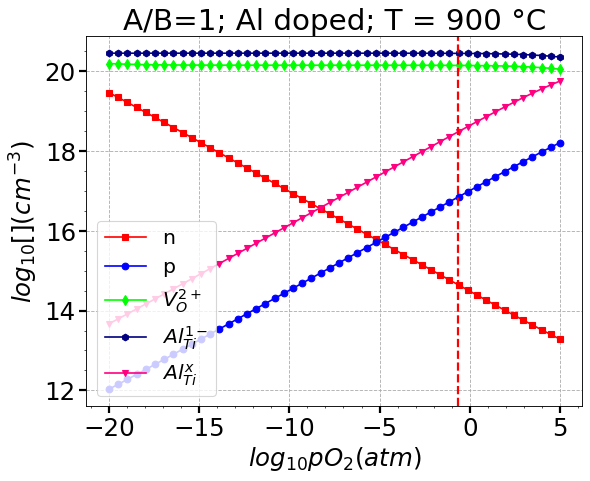

In [3]:
"""
A/B = 1 & High T & Al doped BTO

Ki = 1.06E45*np.exp(-3.15/(k*TK))
KiQ = 1.06E45*np.exp(-3.15/(k*TQK))
KR = 2.4E74*np.exp(-5.88/(k*TK))
KRQ = 2.4E74*np.exp(-5.88/(k*TQK))
KAl = 1.2E23*np.exp(1.04/(k*TK))
KAlQ = 1.2E23*np.exp(1.04/(k*TQK))

Charge neutrality condition: p + 2[VO2+] = n + [AlTi1-]
"""
CAlt = 2.82E20 # total doping concentration of Al; 1.8 mol%

# Calculate each defect concentration as a function of oxygen partial pressure
for i in range(len(a)): 
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: electron concentration in cm-3
        return (x + CAlt*x*(KAl/Ki)/(1+KAl*x/Ki) - (Ki/x) - 2*(KR/((x**2)*(y**(1/2)))))
    sol1 = brentq(f,1,1E30)
    
    n[i] = np.array(sol1).astype(np.float64)
    p[i] = Ki/n[i]
    CVO2[i] = KR/((n[i]**2)*(y**(1/2)))
    CAl1[i] = CAlt*n[i]*(KAl/Ki)/(1+KAl*n[i]/Ki)
    CAl0[i] = CAlt - CAl1[i]

fig = plt.figure(figsize=(8, 6), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'A/B=1; Al doped; T = {TC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(n), marker='s',c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(p),marker='o', c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2),marker='d',c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CAl1),marker='h', c =[0/255, 0/255, 128/255], label = r'$Al_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CAl0),marker='v', c =[255/255, 0/255, 128/255], label = r'$Al_{Ti}^{x}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')

/tmp/ipykernel_1557/2439481084.py:27: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(a),np.log10(CAl0q),marker='v', c =[255/255, 0/255, 128/255], label = r'$Al_{Ti}^{x}$')
/tmp/ipykernel_1557/2439481084.py:27: RuntimeWarning: invalid value encountered in log10
  ax1.plot(np.log10(a),np.log10(CAl0q),marker='v', c =[255/255, 0/255, 128/255], label = r'$Al_{Ti}^{x}$')


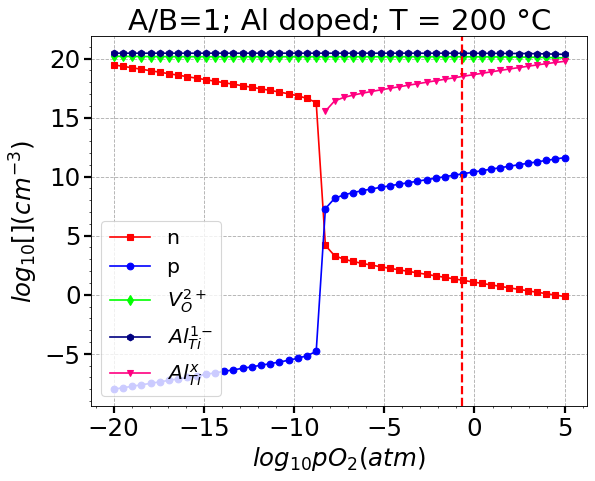

In [4]:
# Calculate each defect concentration as a function of oxygen partial pressure at low T=500 oC with frozen-in ionic defect concentations
for i in range(len(a)):
    y = a[i] # y: oxygen partial pressure in atm
    
    def f(x): # x: oxygen vacancy concentration
        return (x + CAlt*x*(KAlQ/KiQ)/(1+KAlQ*x/KiQ) - (KiQ/x) - 2*CVO2[i])

    sol1 = brentq(f,1E-20,1E40,maxiter=200)
    
    nq[i] = np.array(sol1).astype(np.float64)
    pq[i] = KiQ/nq[i]
    CVO2q[i] = CVO2[i]
    CAl1q[i] = CAlt*nq[i]*(KAlQ/KiQ)/(1+KAlQ*nq[i]/KiQ)
    CAl0q[i] = CAlt - CAl1q[i]

fig = plt.figure(figsize=(8, 6), dpi=80)
ax1= plt.subplot(111)
ax1.set_title(f'A/B=1; Al doped; T = {TQC} \u00B0C')
# ax1.set_ylim(ymin=13, ymax=21)
matplotlib.rcParams.update({'font.size': 22})
ax1.tick_params(length=6, width=2)
ax1.minorticks_on()
ax1.plot(np.log10(a),np.log10(nq), marker='s',c =[255/255, 0/255, 0/255], label=r'n')
ax1.plot(np.log10(a),np.log10(pq),marker='o', c =[0/255, 0/255, 255/255], label = r'p')
ax1.plot(np.log10(a),np.log10(CVO2q),marker='d',c =[0/255, 255/255, 0/255], label = r'$V_O^{2+}$')
ax1.plot(np.log10(a),np.log10(CAl1q),marker='h', c =[0/255, 0/255, 128/255], label = r'$Al_{Ti}^{1-}$')
ax1.plot(np.log10(a),np.log10(CAl0q),marker='v', c =[255/255, 0/255, 128/255], label = r'$Al_{Ti}^{x}$')
ax1.set_xlabel(r'$log_{10} \mathit{p}O_2 (atm)$')
ax1.set_ylabel(r'$log_{10} [ ] (cm^{-3})$')
ax1.legend(loc=3,fontsize='small')
ax1.axvline(x=-0.67, color='r', linestyle='--', linewidth=2)
ax1.grid(True, which='major', linestyle='--')